In [4]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd


# ============================================================
# CONFIGURACIÓN
# ============================================================

VIDEO = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria1.MOV"
)


# Intervalo útil del video
T_INICIO = 1.45
T_FINAL = 5.30


# ============================================================
# CALIBRACIÓN
# ============================================================

# Medición experimental:
#
# 1521 px <--> 147 mm

DIAMETRO_REAL_M = 0.147
DIAMETRO_PX = 1521.0


# Escala espacial
METROS_POR_PX = (
    DIAMETRO_REAL_M / DIAMETRO_PX
)


# Centro del recipiente en la imagen
# Lo usamos como origen x = 0, y = 0

XC_PX = 527.55
YC_PX = 959.40


print("=" * 50)
print("CALIBRACIÓN")
print("=" * 50)

print(
    f"Escala = {METROS_POR_PX:.9e} m/px"
)

print(
    f"Escala = {METROS_POR_PX * 1000:.6f} mm/px"
)

print(
    f"Centro = ({XC_PX:.2f}, {YC_PX:.2f}) px"
)


# ============================================================
# PARÁMETROS DEL TRACKING
# ============================================================

# Amarillo en HSV
HSV_MIN = np.array([
    24,
    80,
    150
])

HSV_MAX = np.array([
    36,
    255,
    255
])


# Área aproximada de la pelotita
AREA_MIN = 700
AREA_MAX = 1800


# Máximo salto admitido entre frames
MAX_SALTO = 30  # px


# Posición aproximada de la pelota
# en el primer frame utilizado, t_video = 1.45 s

POSICION_INICIAL = np.array([
    359.0,
    873.0
])


# ============================================================
# FUNCIÓN PARA BUSCAR OBJETOS AMARILLOS
# ============================================================

kernel = np.ones(
    (5, 5),
    dtype=np.uint8
)


def buscar_candidatos(frame):

    # --------------------------------------------------------
    # Pasar de BGR a HSV
    # --------------------------------------------------------

    hsv = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2HSV
    )


    # --------------------------------------------------------
    # Seleccionar píxeles amarillos
    # --------------------------------------------------------

    mascara = cv2.inRange(
        hsv,
        HSV_MIN,
        HSV_MAX
    )


    # --------------------------------------------------------
    # Limpiar ruido pequeño
    # --------------------------------------------------------

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_OPEN,
        kernel
    )

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_CLOSE,
        kernel
    )


    # --------------------------------------------------------
    # Buscar regiones conectadas
    # --------------------------------------------------------

    contornos, _ = cv2.findContours(
        mascara,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    candidatos = []


    for contorno in contornos:

        area = cv2.contourArea(
            contorno
        )


        # Descartar brillantina muy pequeña
        # y regiones demasiado grandes

        if not (
            AREA_MIN <= area <= AREA_MAX
        ):
            continue


        momentos = cv2.moments(
            contorno
        )


        if momentos["m00"] == 0:
            continue


        # Centroide de la región

        x = (
            momentos["m10"]
            / momentos["m00"]
        )

        y = (
            momentos["m01"]
            / momentos["m00"]
        )


        candidatos.append({
            "x": x,
            "y": y,
            "area": area
        })


    return candidatos


# ============================================================
# ABRIR VIDEO
# ============================================================

cap = cv2.VideoCapture(
    str(VIDEO)
)


if not cap.isOpened():

    raise RuntimeError(
        f"No se pudo abrir:\n{VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)

ancho = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

alto = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)


print()
print("=" * 50)
print("VIDEO")
print("=" * 50)

print(
    f"FPS = {fps:.3f}"
)

print(
    f"Frames totales = {total_frames}"
)

print(
    f"Resolución = {ancho} x {alto}"
)


# ============================================================
# FRAMES A UTILIZAR
# ============================================================

frame_inicio = int(
    round(T_INICIO * fps)
)

frame_final = int(
    round(T_FINAL * fps)
)


cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    frame_inicio
)


print(
    f"Frame inicial = {frame_inicio}"
)

print(
    f"Frame final = {frame_final}"
)


# ============================================================
# VIDEO DE CONTROL
# ============================================================

ruta_preview = (
    VIDEO.parent
    / "trayectoria1_tracking.mp4"
)


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)


writer = cv2.VideoWriter(
    str(ruta_preview),
    fourcc,
    fps,
    (ancho, alto)
)


# ============================================================
# TRACKING
# ============================================================

datos = []

posiciones_previas = []

trayectoria_dibujo = []


posicion_anterior = (
    POSICION_INICIAL.copy()
)


for numero_frame in range(
    frame_inicio,
    frame_final + 1
):

    ok, frame = cap.read()


    if not ok:
        break


    # ========================================================
    # TIEMPO
    # ========================================================

    # Hacemos que el primer punto útil sea t = 0

    tiempo = (
        numero_frame - frame_inicio
    ) / fps


    # ========================================================
    # PREDECIR DÓNDE DEBERÍA ESTAR LA PELOTA
    # ========================================================

    if len(posiciones_previas) >= 2:

        desplazamiento = (
            posiciones_previas[-1]
            - posiciones_previas[-2]
        )


        posicion_predicha = (
            posiciones_previas[-1]
            + desplazamiento
        )


    elif len(posiciones_previas) == 1:

        posicion_predicha = (
            posiciones_previas[-1]
        )


    else:

        posicion_predicha = (
            posicion_anterior
        )


    # ========================================================
    # BUSCAR REGIONES AMARILLAS
    # ========================================================

    candidatos = buscar_candidatos(
        frame
    )


    elegido = None
    mejor_distancia = np.inf


    for candidato in candidatos:

        posicion = np.array([
            candidato["x"],
            candidato["y"]
        ])


        distancia = np.linalg.norm(
            posicion
            - posicion_predicha
        )


        if distancia < mejor_distancia:

            mejor_distancia = distancia
            elegido = candidato


    # ========================================================
    # VALIDAR DETECCIÓN
    # ========================================================

    detectada = (
        elegido is not None
        and
        mejor_distancia <= MAX_SALTO
    )


    if not detectada:

        print(
            f"Pelotita perdida en frame "
            f"{numero_frame}"
        )


        cv2.putText(
            frame,
            "PELOTITA PERDIDA",
            (30, 110),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3
        )


        # El frame sigue apareciendo en el
        # video de control

        writer.write(frame)

        continue


    # ========================================================
    # POSICIÓN DE LA PELOTA EN PÍXELES
    # ========================================================

    x_px = elegido["x"]
    y_px = elegido["y"]


    posicion_actual = np.array([
        x_px,
        y_px
    ])


    posiciones_previas.append(
        posicion_actual
    )


    if len(posiciones_previas) > 3:

        posiciones_previas.pop(0)


    # ========================================================
    # CONVERSIÓN A COORDENADAS FÍSICAS
    # ========================================================

    # El origen está en el centro del recipiente.
    #
    # x positivo hacia la derecha.

    x_m = (
        x_px - XC_PX
    ) * METROS_POR_PX


    # En una imagen, y aumenta hacia abajo.
    #
    # Cambiamos el signo para trabajar con
    # un sistema cartesiano:
    #
    # y positivo hacia arriba.

    y_m = -(
        y_px - YC_PX
    ) * METROS_POR_PX


    # ========================================================
    # GUARDAR DATOS
    # ========================================================

    datos.append({
        "t_s": tiempo,
        "x_m": x_m,
        "y_m": y_m
    })


    # ========================================================
    # DIBUJAR TRACKING
    # ========================================================

    punto = (
        int(round(x_px)),
        int(round(y_px))
    )


    trayectoria_dibujo.append(
        punto
    )


    # Círculo rojo alrededor de la pelota

    cv2.circle(
        frame,
        punto,
        20,
        (0, 0, 255),
        3
    )


    # Centro azul de la pelota

    cv2.circle(
        frame,
        punto,
        4,
        (255, 0, 0),
        -1
    )


    # Centro del sistema de coordenadas

    cv2.circle(
        frame,
        (
            int(round(XC_PX)),
            int(round(YC_PX))
        ),
        7,
        (255, 0, 255),
        -1
    )


    # Trayectoria acumulada

    if len(trayectoria_dibujo) >= 2:

        puntos = np.array(
            trayectoria_dibujo,
            dtype=np.int32
        )


        cv2.polylines(
            frame,
            [puntos],
            False,
            (0, 0, 255),
            2
        )


    # Tiempo

    cv2.putText(
        frame,
        f"t = {tiempo:.2f} s",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 255, 255),
        3
    )


    writer.write(frame)


# ============================================================
# CERRAR ARCHIVOS
# ============================================================

cap.release()
writer.release()


# ============================================================
# CREAR DATAFRAME
# ============================================================

df = pd.DataFrame(
    datos
)


# ============================================================
# GUARDAR CSV PARA LA PINN
# ============================================================

ruta_csv = (
    VIDEO.parent
    / "trayectoria1_PINN.csv"
)


df.to_csv(
    ruta_csv,
    index=False
)


# ============================================================
# RESULTADOS
# ============================================================

print()
print("=" * 50)
print("LISTO")
print("=" * 50)

print(
    f"Puntos obtenidos = {len(df)}"
)

print()

print(
    f"CSV:\n{ruta_csv}"
)

print()

print(
    f"Preview:\n{ruta_preview}"
)

print()

print("Primeras filas:")

print(
    df.head()
)

CALIBRACIÓN
Escala = 9.664694280e-05 m/px
Escala = 0.096647 mm/px
Centro = (527.55, 959.40) px

VIDEO
FPS = 59.921
Frames totales = 531
Resolución = 1080 x 1920
Frame inicial = 87
Frame final = 318

LISTO
Puntos obtenidos = 232

CSV:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria1_PINN.csv

Preview:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria1_tracking.mp4

Primeras filas:
        t_s       x_m       y_m
0  0.000000 -0.016295  0.008312
1  0.016689 -0.016716  0.007263
2  0.033377 -0.017010  0.006230
3  0.050066 -0.017228  0.005184
4  0.066755 -0.017439  0.004104


CALIBRACIÓN
Escala = 9.664694280e-05 m/px
Escala = 0.096647 mm/px
Centro = (527.55, 959.40) px

VIDEO
FPS = 59.923
Frames totales = 465
Resolución = 1080 x 1920
Frame inicial = 102
Frame final = 258
Duración utilizada = 2.60 s


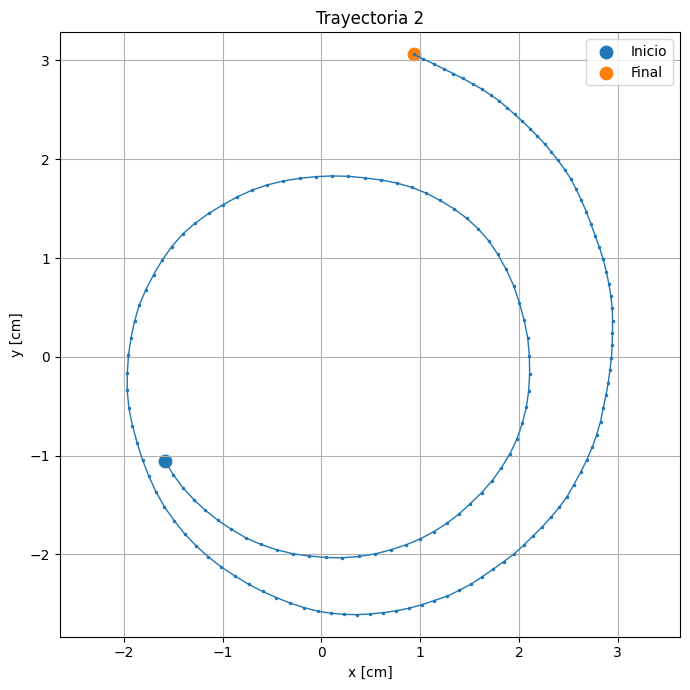


LISTO
Puntos obtenidos = 157
Duración final = 2.603 s

CSV:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria2_PINN.csv

Preview:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria2_tracking.mp4

Gráfico:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria2_grafico.png

        t_s       x_m       y_m
0  0.000000 -0.015819 -0.010578
1  0.016688 -0.014986 -0.011937
2  0.033376 -0.014027 -0.013244
3  0.050065 -0.012903 -0.014459
4  0.066753 -0.011744 -0.015537


In [13]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

VIDEO = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria2.MOV"
)


# ============================================================
# INTERVALO ELEGIDO
# ============================================================

# Intervalo seleccionado mirando el video y la trayectoria.
#
# Antes de ~1.7 s la partícula vuelve a recorrer regiones
# muy próximas a otras ya visitadas.
#
# Después de ~4.3 s empieza a acercarse a la región donde
# el tracking se vuelve menos confiable.

T_INICIO = 1.70
T_FINAL = 4.30


# ============================================================
# CALIBRACIÓN
# ============================================================

# 1521 px <--> 147 mm

DIAMETRO_REAL_M = 0.147
DIAMETRO_PX = 1521.0


METROS_POR_PX = (
    DIAMETRO_REAL_M
    / DIAMETRO_PX
)


# Mismo sistema de coordenadas que trayectoria1
XC_PX = 527.55
YC_PX = 959.40


print("=" * 50)
print("CALIBRACIÓN")
print("=" * 50)

print(
    f"Escala = {METROS_POR_PX:.9e} m/px"
)

print(
    f"Escala = "
    f"{METROS_POR_PX * 1000:.6f} mm/px"
)

print(
    f"Centro = "
    f"({XC_PX:.2f}, {YC_PX:.2f}) px"
)


# ============================================================
# PARÁMETROS DEL TRACKING
# ============================================================

HSV_MIN = np.array([
    24,
    80,
    150
])


HSV_MAX = np.array([
    36,
    255,
    255
])


AREA_MIN = 700
AREA_MAX = 1800


MAX_SALTO = 30


# Posición de la pelota en aproximadamente t = 1.70 s

POSICION_INICIAL = np.array([
    363.9,
    1068.9
])


# ============================================================
# FUNCIÓN PARA BUSCAR OBJETOS AMARILLOS
# ============================================================

kernel = np.ones(
    (5, 5),
    dtype=np.uint8
)


def buscar_candidatos(frame):

    hsv = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2HSV
    )


    mascara = cv2.inRange(
        hsv,
        HSV_MIN,
        HSV_MAX
    )


    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_OPEN,
        kernel
    )


    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_CLOSE,
        kernel
    )


    contornos, _ = cv2.findContours(
        mascara,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    candidatos = []


    for contorno in contornos:

        area = cv2.contourArea(
            contorno
        )


        if not (
            AREA_MIN <= area <= AREA_MAX
        ):
            continue


        momentos = cv2.moments(
            contorno
        )


        if momentos["m00"] == 0:
            continue


        x = (
            momentos["m10"]
            / momentos["m00"]
        )


        y = (
            momentos["m01"]
            / momentos["m00"]
        )


        candidatos.append({
            "x": x,
            "y": y,
            "area": area
        })


    return candidatos


# ============================================================
# ABRIR VIDEO
# ============================================================

cap = cv2.VideoCapture(
    str(VIDEO)
)


if not cap.isOpened():

    raise RuntimeError(
        f"No se pudo abrir:\n{VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)


total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)


ancho = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)


alto = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)


print()
print("=" * 50)
print("VIDEO")
print("=" * 50)

print(
    f"FPS = {fps:.3f}"
)

print(
    f"Frames totales = {total_frames}"
)

print(
    f"Resolución = {ancho} x {alto}"
)


# ============================================================
# FRAMES A UTILIZAR
# ============================================================

frame_inicio = int(
    round(
        T_INICIO * fps
    )
)


frame_final = int(
    round(
        T_FINAL * fps
    )
)


cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    frame_inicio
)


print(
    f"Frame inicial = {frame_inicio}"
)

print(
    f"Frame final = {frame_final}"
)

print(
    f"Duración utilizada = "
    f"{T_FINAL - T_INICIO:.2f} s"
)


# ============================================================
# VIDEO DE CONTROL
# ============================================================

ruta_preview = (
    VIDEO.parent
    / "trayectoria2_tracking.mp4"
)


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)


writer = cv2.VideoWriter(
    str(ruta_preview),
    fourcc,
    fps,
    (ancho, alto)
)


# ============================================================
# TRACKING
# ============================================================

datos = []

posiciones_previas = []

trayectoria_dibujo = []


posicion_anterior = (
    POSICION_INICIAL.copy()
)


for numero_frame in range(
    frame_inicio,
    frame_final + 1
):

    ok, frame = cap.read()


    if not ok:
        break


    # ========================================================
    # TIEMPO
    # ========================================================

    # El nuevo CSV empieza en t = 0

    tiempo = (
        numero_frame
        - frame_inicio
    ) / fps


    # ========================================================
    # PREDECIR POSICIÓN
    # ========================================================

    if len(posiciones_previas) >= 2:

        desplazamiento = (
            posiciones_previas[-1]
            - posiciones_previas[-2]
        )


        posicion_predicha = (
            posiciones_previas[-1]
            + desplazamiento
        )


    elif len(posiciones_previas) == 1:

        posicion_predicha = (
            posiciones_previas[-1]
        )


    else:

        posicion_predicha = (
            posicion_anterior
        )


    # ========================================================
    # BUSCAR CANDIDATOS
    # ========================================================

    candidatos = buscar_candidatos(
        frame
    )


    elegido = None
    mejor_distancia = np.inf


    for candidato in candidatos:

        posicion = np.array([
            candidato["x"],
            candidato["y"]
        ])


        distancia = np.linalg.norm(
            posicion
            - posicion_predicha
        )


        if distancia < mejor_distancia:

            mejor_distancia = distancia
            elegido = candidato


    # ========================================================
    # VALIDAR DETECCIÓN
    # ========================================================

    detectada = (
        elegido is not None
        and
        mejor_distancia <= MAX_SALTO
    )


    if not detectada:

        print(
            f"Pelotita perdida en frame "
            f"{numero_frame}, "
            f"t = {tiempo:.3f} s"
        )


        cv2.putText(
            frame,
            "PELOTITA PERDIDA",
            (30, 110),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3
        )


        writer.write(
            frame
        )

        continue


    # ========================================================
    # POSICIÓN EN PÍXELES
    # ========================================================

    x_px = elegido["x"]
    y_px = elegido["y"]


    posicion_actual = np.array([
        x_px,
        y_px
    ])


    posiciones_previas.append(
        posicion_actual
    )


    if len(posiciones_previas) > 3:

        posiciones_previas.pop(0)


    # ========================================================
    # CONVERSIÓN A METROS
    # ========================================================

    x_m = (
        x_px
        - XC_PX
    ) * METROS_POR_PX


    y_m = -(
        y_px
        - YC_PX
    ) * METROS_POR_PX


    # ========================================================
    # GUARDAR DATOS
    # ========================================================

    datos.append({
        "t_s": tiempo,
        "x_m": x_m,
        "y_m": y_m
    })


    # ========================================================
    # DIBUJAR TRACKING
    # ========================================================

    punto = (
        int(round(x_px)),
        int(round(y_px))
    )


    trayectoria_dibujo.append(
        punto
    )


    cv2.circle(
        frame,
        punto,
        20,
        (0, 0, 255),
        3
    )


    cv2.circle(
        frame,
        punto,
        4,
        (255, 0, 0),
        -1
    )


    cv2.circle(
        frame,
        (
            int(round(XC_PX)),
            int(round(YC_PX))
        ),
        7,
        (255, 0, 255),
        -1
    )


    if len(trayectoria_dibujo) >= 2:

        puntos = np.array(
            trayectoria_dibujo,
            dtype=np.int32
        )


        cv2.polylines(
            frame,
            [puntos],
            False,
            (0, 0, 255),
            2
        )


    cv2.putText(
        frame,
        f"t = {tiempo:.2f} s",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 255, 255),
        3
    )


    writer.write(
        frame
    )


# ============================================================
# CERRAR VIDEO
# ============================================================

cap.release()
writer.release()


# ============================================================
# CREAR CSV
# ============================================================

df = pd.DataFrame(
    datos
)


ruta_csv = (
    VIDEO.parent
    / "trayectoria2_PINN.csv"
)


df.to_csv(
    ruta_csv,
    index=False
)


# ============================================================
# GRÁFICO DE LA TRAYECTORIA
# ============================================================

x_cm = (
    100 * df["x_m"]
)

y_cm = (
    100 * df["y_m"]
)


plt.figure(
    figsize=(7, 7)
)


plt.plot(
    x_cm,
    y_cm,
    ".-",
    markersize=3,
    linewidth=1
)


plt.scatter(
    x_cm.iloc[0],
    y_cm.iloc[0],
    s=80,
    label="Inicio"
)


plt.scatter(
    x_cm.iloc[-1],
    y_cm.iloc[-1],
    s=80,
    label="Final"
)


plt.xlabel(
    "x [cm]"
)

plt.ylabel(
    "y [cm]"
)

plt.title(
    "Trayectoria 2"
)

plt.axis(
    "equal"
)

plt.grid()

plt.legend()

plt.tight_layout()


ruta_grafico = (
    VIDEO.parent
    / "trayectoria2_grafico.png"
)


plt.savefig(
    ruta_grafico,
    dpi=200
)

plt.show()


# ============================================================
# RESULTADOS
# ============================================================

print()
print("=" * 50)
print("LISTO")
print("=" * 50)

print(
    f"Puntos obtenidos = {len(df)}"
)

print(
    f"Duración final = "
    f"{df['t_s'].max():.3f} s"
)

print()

print(
    f"CSV:\n{ruta_csv}"
)

print()

print(
    f"Preview:\n{ruta_preview}"
)

print()

print(
    f"Gráfico:\n{ruta_grafico}"
)

print()

print(
    df.head()
)

CALIBRACIÓN
Escala = 9.664694280e-05 m/px
Escala = 0.096647 mm/px
Centro = (527.55, 959.40) px

VIDEO
FPS = 59.923
Frames totales = 2644
Duración = 44.12 s
Resolución = 1080 x 1920

INTERVALO PARA LA PINN
Inicio video = 17.00 s
Duración pedida = 4.00 s
Frame inicial = 1019
Frame final = 1259

INFORMACIÓN DEL TRAMO
Radio inicial = 2.584 cm
Radio mínimo = 1.891 cm
Radio máximo = 2.601 cm
Radio final = 1.894 cm


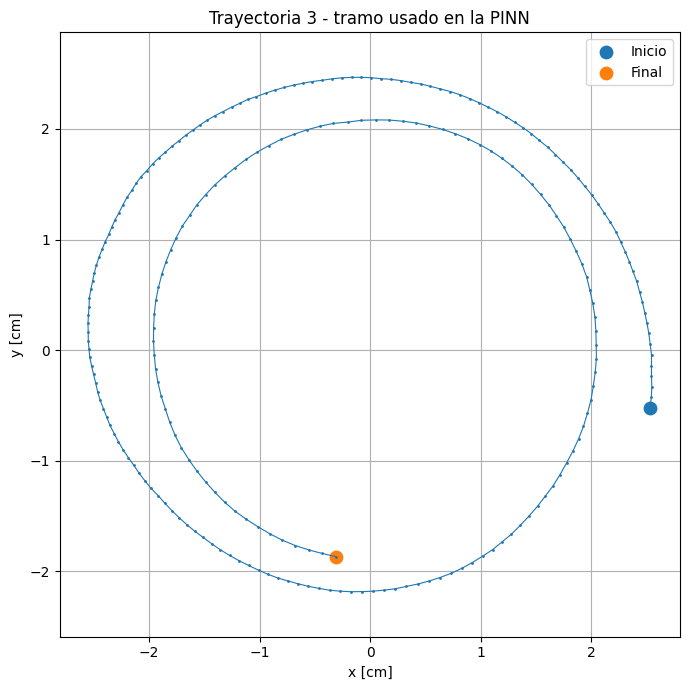


LISTO
Puntos obtenidos = 241
Tiempo final del CSV = 4.0051 s

CSV:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria3_PINN.csv

Preview:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria3_tracking.mp4

Gráfico:
C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria3_grafico.png

        t_s       x_m       y_m
0  0.000000  0.025309 -0.005220
1  0.016688  0.025421 -0.004254
2  0.033376  0.025461 -0.003324
3  0.050064  0.025431 -0.002382
4  0.066752  0.025429 -0.001434


In [12]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURACIÓN
# ============================================================

VIDEO = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos\trayectoria3.MOV"
)


# ============================================================
# INTERVALO SELECCIONADO PARA LA PINN
# ============================================================

# Después de analizar toda la trayectoria, usamos este tramo
# porque presenta bastante variación radial y unas 2 vueltas
# completas, sin llegar a la región problemática del borde.

# ============================================================
# INTERVALO SELECCIONADO PARA LA PINN
# ============================================================

T_INICIO = 17.00
DURACION = 4.00


# ============================================================
# CALIBRACIÓN
# ============================================================

# Misma cámara y mismo montaje que las trayectorias anteriores
#
# 1521 px <--> 147 mm

DIAMETRO_REAL_M = 0.147
DIAMETRO_PX = 1521.0


METROS_POR_PX = (
    DIAMETRO_REAL_M / DIAMETRO_PX
)


# Mismo origen espacial usado para las otras trayectorias

XC_PX = 527.55
YC_PX = 959.40


print("=" * 50)
print("CALIBRACIÓN")
print("=" * 50)

print(
    f"Escala = {METROS_POR_PX:.9e} m/px"
)

print(
    f"Escala = {METROS_POR_PX * 1000:.6f} mm/px"
)

print(
    f"Centro = ({XC_PX:.2f}, {YC_PX:.2f}) px"
)


# ============================================================
# PARÁMETROS DEL TRACKING
# ============================================================

HSV_MIN = np.array([
    24,
    80,
    150
])

HSV_MAX = np.array([
    36,
    255,
    255
])


AREA_MIN = 550
AREA_MAX = 900


MAX_SALTO = 30


# Posición aproximada de la pelotita móvil
# en t = 3.60 s del video original.

POSICION_INICIAL = np.array([
    789.46,
    1013.53
])


# ============================================================
# FUNCIÓN PARA BUSCAR CANDIDATOS AMARILLOS
# ============================================================

kernel = np.ones(
    (5, 5),
    dtype=np.uint8
)


def buscar_candidatos(frame):

    hsv = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2HSV
    )


    mascara = cv2.inRange(
        hsv,
        HSV_MIN,
        HSV_MAX
    )


    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_OPEN,
        kernel
    )

    mascara = cv2.morphologyEx(
        mascara,
        cv2.MORPH_CLOSE,
        kernel
    )


    contornos, _ = cv2.findContours(
        mascara,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    candidatos = []


    for contorno in contornos:

        area = cv2.contourArea(
            contorno
        )


        if not (
            AREA_MIN <= area <= AREA_MAX
        ):
            continue


        momentos = cv2.moments(
            contorno
        )


        if momentos["m00"] == 0:
            continue


        x = (
            momentos["m10"]
            / momentos["m00"]
        )

        y = (
            momentos["m01"]
            / momentos["m00"]
        )


        candidatos.append({
            "x": x,
            "y": y,
            "area": area
        })


    return candidatos


# ============================================================
# ABRIR VIDEO
# ============================================================

cap = cv2.VideoCapture(
    str(VIDEO)
)


if not cap.isOpened():

    raise RuntimeError(
        f"No se pudo abrir:\n{VIDEO}"
    )


fps = cap.get(
    cv2.CAP_PROP_FPS
)

total_frames = int(
    cap.get(
        cv2.CAP_PROP_FRAME_COUNT
    )
)

ancho = int(
    cap.get(
        cv2.CAP_PROP_FRAME_WIDTH
    )
)

alto = int(
    cap.get(
        cv2.CAP_PROP_FRAME_HEIGHT
    )
)


duracion_video = (
    total_frames / fps
)


print()
print("=" * 50)
print("VIDEO")
print("=" * 50)

print(
    f"FPS = {fps:.3f}"
)

print(
    f"Frames totales = {total_frames}"
)

print(
    f"Duración = {duracion_video:.2f} s"
)

print(
    f"Resolución = {ancho} x {alto}"
)


# ============================================================
# FRAMES A UTILIZAR
# ============================================================

frame_inicio = int(
    round(T_INICIO * fps)
)


# Así garantizamos aproximadamente 4 segundos
# independientemente del FPS real del video.

cantidad_intervalos = int(
    round(DURACION * fps)
)


frame_final = (
    frame_inicio
    + cantidad_intervalos
)


cap.set(
    cv2.CAP_PROP_POS_FRAMES,
    frame_inicio
)


print()
print("=" * 50)
print("INTERVALO PARA LA PINN")
print("=" * 50)

print(
    f"Inicio video = {T_INICIO:.2f} s"
)

print(
    f"Duración pedida = {DURACION:.2f} s"
)

print(
    f"Frame inicial = {frame_inicio}"
)

print(
    f"Frame final = {frame_final}"
)


# ============================================================
# VIDEO DE CONTROL
# ============================================================

ruta_preview = (
    VIDEO.parent
    / "trayectoria3_tracking.mp4"
)


fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)


writer = cv2.VideoWriter(
    str(ruta_preview),
    fourcc,
    fps,
    (ancho, alto)
)


# ============================================================
# TRACKING
# ============================================================

datos = []

posiciones_previas = []

trayectoria_dibujo = []


posicion_anterior = (
    POSICION_INICIAL.copy()
)


for numero_frame in range(
    frame_inicio,
    frame_final + 1
):

    ok, frame = cap.read()


    if not ok:
        break


    # ========================================================
    # TIEMPO
    # ========================================================

    # El CSV vuelve a empezar en t = 0.

    tiempo = (
        numero_frame
        - frame_inicio
    ) / fps


    # ========================================================
    # PREDECIR POSICIÓN
    # ========================================================

    if len(posiciones_previas) >= 2:

        desplazamiento = (
            posiciones_previas[-1]
            - posiciones_previas[-2]
        )


        posicion_predicha = (
            posiciones_previas[-1]
            + desplazamiento
        )


    elif len(posiciones_previas) == 1:

        posicion_predicha = (
            posiciones_previas[-1]
        )


    else:

        posicion_predicha = (
            posicion_anterior
        )


    # ========================================================
    # BUSCAR CANDIDATOS
    # ========================================================

    candidatos = buscar_candidatos(
        frame
    )


    elegido = None
    mejor_distancia = np.inf


    for candidato in candidatos:

        posicion = np.array([
            candidato["x"],
            candidato["y"]
        ])


        distancia = np.linalg.norm(
            posicion
            - posicion_predicha
        )


        if distancia < mejor_distancia:

            mejor_distancia = distancia
            elegido = candidato


    # ========================================================
    # VALIDAR DETECCIÓN
    # ========================================================

    detectada = (
        elegido is not None
        and
        mejor_distancia <= MAX_SALTO
    )


    if not detectada:

        print(
            f"Pelotita perdida en frame "
            f"{numero_frame}, "
            f"t = {tiempo:.3f} s"
        )


        cv2.putText(
            frame,
            "PELOTITA PERDIDA",
            (30, 110),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3
        )


        writer.write(
            frame
        )

        continue


    # ========================================================
    # POSICIÓN EN PÍXELES
    # ========================================================

    x_px = elegido["x"]
    y_px = elegido["y"]


    posicion_actual = np.array([
        x_px,
        y_px
    ])


    posiciones_previas.append(
        posicion_actual
    )


    if len(posiciones_previas) > 3:

        posiciones_previas.pop(0)


    # ========================================================
    # CONVERSIÓN A METROS
    # ========================================================

    x_m = (
        x_px - XC_PX
    ) * METROS_POR_PX


    y_m = -(
        y_px - YC_PX
    ) * METROS_POR_PX


    # ========================================================
    # GUARDAR DATOS
    # ========================================================

    datos.append({
        "t_s": tiempo,
        "x_m": x_m,
        "y_m": y_m
    })


    # ========================================================
    # DIBUJAR TRACKING
    # ========================================================

    punto = (
        int(round(x_px)),
        int(round(y_px))
    )


    trayectoria_dibujo.append(
        punto
    )


    # Pelotita

    cv2.circle(
        frame,
        punto,
        20,
        (0, 0, 255),
        3
    )


    cv2.circle(
        frame,
        punto,
        4,
        (255, 0, 0),
        -1
    )


    # Centro de coordenadas

    cv2.circle(
        frame,
        (
            int(round(XC_PX)),
            int(round(YC_PX))
        ),
        7,
        (255, 0, 255),
        -1
    )


    # Trayectoria

    if len(trayectoria_dibujo) >= 2:

        puntos = np.array(
            trayectoria_dibujo,
            dtype=np.int32
        )


        cv2.polylines(
            frame,
            [puntos],
            False,
            (0, 0, 255),
            2
        )


    cv2.putText(
        frame,
        f"t = {tiempo:.2f} s",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 255, 255),
        3
    )


    writer.write(
        frame
    )


# ============================================================
# CERRAR VIDEO
# ============================================================

cap.release()
writer.release()


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(
    datos
)


if len(df) == 0:

    raise RuntimeError(
        "No se detectó la pelotita."
    )


# ============================================================
# GUARDAR CSV PARA LA PINN
# ============================================================

# Se sobrescribe deliberadamente el archivo anterior.

ruta_csv = (
    VIDEO.parent
    / "trayectoria3_PINN.csv"
)


df.to_csv(
    ruta_csv,
    index=False
)


# ============================================================
# INFORMACIÓN RADIAL DEL TRAMO
# ============================================================

radio_m = np.sqrt(
    df["x_m"]**2
    + df["y_m"]**2
)


print()
print("=" * 50)
print("INFORMACIÓN DEL TRAMO")
print("=" * 50)

print(
    f"Radio inicial = "
    f"{radio_m.iloc[0] * 100:.3f} cm"
)

print(
    f"Radio mínimo = "
    f"{radio_m.min() * 100:.3f} cm"
)

print(
    f"Radio máximo = "
    f"{radio_m.max() * 100:.3f} cm"
)

print(
    f"Radio final = "
    f"{radio_m.iloc[-1] * 100:.3f} cm"
)


# ============================================================
# GRÁFICO DE LA TRAYECTORIA
# ============================================================

x_cm = (
    df["x_m"] * 100
)

y_cm = (
    df["y_m"] * 100
)


plt.figure(
    figsize=(7, 7)
)


plt.plot(
    x_cm,
    y_cm,
    ".-",
    markersize=2,
    linewidth=0.8
)


plt.scatter(
    x_cm.iloc[0],
    y_cm.iloc[0],
    s=80,
    label="Inicio"
)


plt.scatter(
    x_cm.iloc[-1],
    y_cm.iloc[-1],
    s=80,
    label="Final"
)


plt.xlabel(
    "x [cm]"
)

plt.ylabel(
    "y [cm]"
)

plt.title(
    "Trayectoria 3 - tramo usado en la PINN"
)


plt.axis(
    "equal"
)

plt.grid()

plt.legend()

plt.tight_layout()


ruta_grafico = (
    VIDEO.parent
    / "trayectoria3_grafico.png"
)


plt.savefig(
    ruta_grafico,
    dpi=200
)


plt.show()


# ============================================================
# RESULTADOS
# ============================================================

print()
print("=" * 50)
print("LISTO")
print("=" * 50)

print(
    f"Puntos obtenidos = {len(df)}"
)

print(
    f"Tiempo final del CSV = "
    f"{df['t_s'].iloc[-1]:.4f} s"
)

print()

print(
    f"CSV:\n{ruta_csv}"
)

print()

print(
    f"Preview:\n{ruta_preview}"
)

print()

print(
    f"Gráfico:\n{ruta_grafico}"
)

print()

print(
    df.head()
)